## IMPORTAÇÕES

In [1]:
import pandas as pd
from pathlib import Path
from src.config import settings
from src.transform import reshape
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## CARREGAMENTO DAS BASES

In [3]:
CENSO_PATH          = settings.EXTERNAL_DATA_PATH / 'censo_demografico_2022.csv'
CENSO_PCD_PATH      = settings.EXTERNAL_DATA_PATH / 'censo_demografico_pcd_2022.csv'
IBGE_TABELA         = settings.EXTERNAL_DATA_PATH / 'POP2024_20241230.xls'
GEO_JSON            = settings.EXTERNAL_DATA_PATH / 'br_states.json'
TABELA_SNIIC        = settings.FINAL_DATA_PATH / 'tabela_final_3_2_2026_14_22.parquet'
ADESAO_FILE_PATH    = settings.EXTERNAL_DATA_PATH / 'Adesão - Politica Nacional Aldir Blanc.xlsx'



In [4]:
# IBGE - CENSO
df_censo        = pd.read_csv(CENSO_PATH, sep=';')
df_censo_pcd    = pd.read_csv(CENSO_PCD_PATH, sep=';')
df_censo_pcd.rename(columns={'Cód.':'cod_ibge', 'Total':'pop_pcd'}, inplace=True)

# IBGE - ESTADOS MUN
df_ibge_mun        = pd.read_excel(IBGE_TABELA, sheet_name='MUNICÍPIOS')
df_ibge_est        = pd.read_excel(IBGE_TABELA)

# SNIIC
df_sniic = pd.read_parquet(TABELA_SNIIC, engine='fastparquet')

# TABELA ADESÃO
df_adesao          = pd.read_excel(ADESAO_FILE_PATH)


## TABELA DE ADESÃO


In [5]:

df_adesao=df_adesao.rename(columns={
    'Código IBGE': 'cod_ibge',
    'UF do Ente': 'uf',
    'População': 'populacao',
    'Valor do Plano':'valor_plano'
})
df_adesao = df_adesao[['cod_ibge', 'uf']] 
df_adesao = df_adesao.drop_duplicates()
df_adesao = df_adesao.reset_index(drop=True)

## CENSO DEMOGRÁFICO

In [6]:
df_censo = df_censo.merge(
    right=df_censo_pcd[['cod_ibge', 'pop_pcd']],
    how='left',
    on='cod_ibge'   
)

In [7]:
# RENOMEIA AS COLUNAS DA TABELA ORIGEM
df_censo = df_censo.rename(columns=settings.RENAME_COLUMNS_CENSO)

In [8]:
# DEFINE COLUNA PESSOAS NEGRAS
df_censo["pop_pessoas_negras"] = df_censo["pop_preta"] + df_censo["pop_parda"]

In [9]:
# CRIA A COLUNA PERCENTUAL PARA CADA CATEGORIA DE POPULAÇÃO
df_censo[settings.COLS_NUM] = df_censo[settings.COLS_NUM].apply(
    pd.to_numeric, errors="coerce"
)

for col in settings.COLS_POP:
    df_censo[f"rel_{col}"] = df_censo[col] / df_censo["pop_total"]

In [10]:
# PASSA COD_IBGE PARA STRING, ESSA SERÁ NOSSA CHAVE PRIMÁRIA
df_censo['cod_ibge'] = df_censo['cod_ibge'].astype(str) 

## TABELA SNIIC

### ESTADOS

In [11]:
df_sniic_estados = df_sniic.loc[df_sniic['tipo_ente'] == 'ESTADO']

In [12]:
# TRATAMENTO TABELA_SNIIC - CRIAMOS A TABELA DE VALORES AGREGADO
df_sniic_estados = reshape.agregar_tabela_sniic(df=df_sniic_estados)

In [13]:
# CALCULO DE VALOR E VAGA
df_sniic_estados = reshape.calcular_totais_cotas(df=df_sniic_estados)

In [14]:
# CALCULA PROPORÇÃO VALOR VAGA
df_sniic_estados = reshape.calcular_proporcoes_valor_e_vagas(df=df_sniic_estados)

In [15]:
df_sniic_censo_estados = df_sniic_estados.merge(
    right=df_censo,
    on='cod_ibge',
    how='left'
)

### MUNICÍPIOS

In [16]:
def pipeline(df, tipo_ente=None):
    if tipo_ente != None:
        df = df.loc[df['tipo_ente'] == tipo_ente]

    # TRATAMENTO TABELA_SNIIC - CRIAMOS A TABELA DE VALORES AGREGADO
    df = reshape.agregar_tabela_sniic(df=df)

    # CALCULO DE VALOR E VAGA
    df = reshape.calcular_totais_cotas(df=df)


    # MERGE DF E DF_ADESAO
    df = df.merge(right=df_adesao, how='left', on='cod_ibge')

    if tipo_ente != "ESTADO":
        # CORRIGE O RIO DE JANEIRO
        df.loc[df['ente_federativo'] == 'RIO DE JANEIRO (capital)', 'uf'] = 'RJ'
    
    # TRANSFORMA VALORES EM VAGAS
    df = reshape.calcular_proporcoes_valor_e_vagas(df=df)

    return df

In [17]:
df_sniic_capitais = pipeline(df_sniic, tipo_ente='CAPITAL')

In [18]:
df_sniic_capitais

,cod_ibge,ente_federativo,tipo_ente,sum_valor_total,sum_valor_cotas_negras,sum_valor_cotas_indigenas,sum_valor_cotas_pcd,sum_vagas_totais,sum_vagas_cotas_negras,sum_vagas_cotas_indigenas,...,sum_vagas_cotas_total,uf,rel_valor_cotas_negras,rel_valor_cotas_indigenas,rel_valor_cotas_pcd,rel_valor_cotas_total,rel_vagas_cotas_negras,rel_vagas_cotas_indigenas,rel_vagas_cotas_pcd,rel_vagas_cotas_totais
0,1100205,PORTO VELHO,CAPITAL,"3,672,808.73","928,019.66","442,471.97","141,445.98",117,28,14,...,47,RO,0.25,0.12,0.04,0.41,0.24,0.12,0.04,0.40
1,1200401,RIO BRANCO,CAPITAL,"4,088,000.00","909,432.17","385,000.00","209,954.38",214,44,28,...,82,AC,0.22,0.09,0.05,0.37,0.21,0.13,0.05,0.38
2,1302603,MANAUS,CAPITAL,"13,366,857.14","3,133,430.40","3,133,430.40","736,104.44",414,95,95,...,213,AM,0.23,0.23,0.06,0.52,0.23,0.23,0.06,0.51
3,1400100,BOA VISTA,CAPITAL,"3,565,968.00","753,326.25","265,330.50","132,665.25",265,66,26,...,105,RR,0.21,0.07,0.04,0.32,0.25,0.10,0.05,0.40
4,1501402,BELÉM,CAPITAL,"5,224,089.00","1,306,022.25","522,408.90","261,204.45",100,25,10,...,40,PA,0.25,0.10,0.05,0.40,0.25,0.10,0.05,0.40
5,1600303,MACAPÁ,CAPITAL,"2,538,254.06","646,334.77","258,459.33","120,185.35",151,38,15,...,60,AP,0.25,0.10,0.05,0.40,0.25,0.10,0.05,0.40
6,1721000,PALMAS,CAPITAL,"2,114,500.00","534,662.77","201,422.51","95,711.26",92,23,9,...,36,TO,0.25,0.10,0.05,0.39,0.25,0.10,0.04,0.39
7,2111300,RIO DE JANEIRO (capital),CAPITAL,"37,165,000.00","7,926,962.08","3,612,111.99","1,937,306.00",234,51,23,...,87,RJ,0.21,0.10,0.05,0.36,0.22,0.10,0.06,0.37
8,2111300,SÃO LUIS,CAPITAL,"6,950,500.00","1,696,609.26","694,191.53","283,500.93",294,73,29,...,116,MA,0.24,0.10,0.04,0.38,0.25,0.10,0.05,0.39
9,2211001,TERESINA,CAPITAL,"5,453,008.73","1,300,846.52","673,182.06","449,077.00",143,36,15,...,60,PI,0.24,0.12,0.08,0.44,0.25,0.10,0.06,0.42


In [19]:
df_sniic_censo_capitais = df_sniic_capitais.merge(
    right=df_censo,
    on='cod_ibge',
    how='left'
)

### GERAL

In [20]:
df_sniic_geral = pipeline(df=df_sniic)

In [21]:
df_sniic_censo_geral = df_sniic_geral.merge(
    right=df_censo,
    on='cod_ibge',
    how='left'
)

## ANÁLISE

In [22]:
def corr(df, col_x, col_y):
    x = df[col_x].astype(float)
    y = df[col_y].astype(float)  # ou sua coluna rel_cotas_pessoas_negras

    # limpeza básica
    m = x.notna() & y.notna()
    xv, yv = x[m], y[m]

    pearson_r, pearson_p = pearsonr(xv, yv)
    spearman_r, spearman_p = spearmanr(xv, yv)

    resultados = pd.DataFrame([{
        "n": int(m.sum()),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    }])

    return resultados

In [23]:
def plot_corr(df, col_x, col_y):
    x = df[col_x].astype(float)
    y = df[col_y].astype(float)

    m = x.notna() & y.notna()
    xv, yv = x[m].to_numpy(), y[m].to_numpy()

    # correlações
    r_p, p_p = pearsonr(xv, yv)
    r_s, p_s = spearmanr(xv, yv)

    # reta OLS
    b1, b0 = np.polyfit(xv, yv, 1)
    xx = np.linspace(xv.min(), xv.max(), 200)
    yy = b1 * xx + b0

    plt.figure(figsize=(8, 6))
    plt.scatter(xv, yv)
    plt.plot(xx, yy)

    plt.xlabel(f"Proporção da população  ({col_x})")
    plt.ylabel(f"Proporção do valor em cotas  ({col_y})")
    plt.title(f"Dispersão + tendência | Pearson r={r_p:.2f} (p={p_p:.2f}) | Spearman ρ={r_s:.2f} (p={p_s:.2f})")
    plt.grid(True, alpha=0.3)
    plt.show()


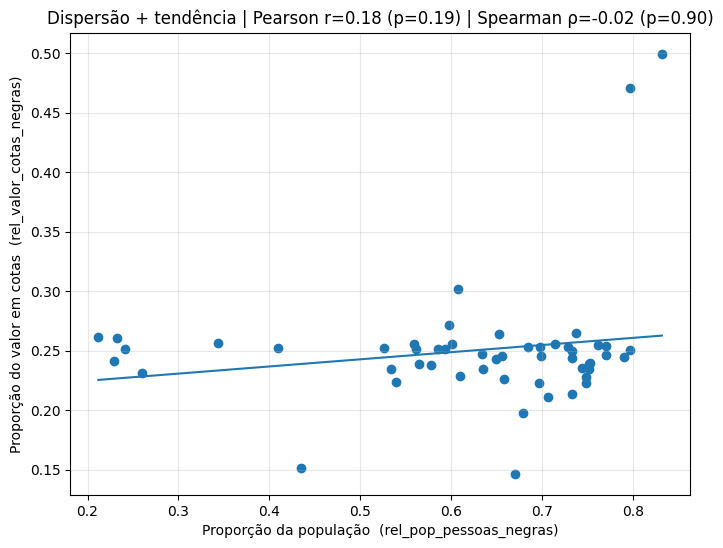

In [27]:
# Pessoas Negras
plot_corr(df=df_sniic_censo_geral, col_x='rel_pop_pessoas_negras', col_y='rel_valor_cotas_negras')

In [67]:
df_sniic_censo.loc[df_sniic_censo['rel_pop_pessoas_negras'] > 0.7][['ente_federativo', 'rel_pop_pessoas_negras', 'rel_valor_cotas_negras']].sort_values(by='rel_pop_pessoas_negras', ascending=False)

,ente_federativo,rel_pop_pessoas_negras,rel_valor_cotas_negras
15,BAHIA,0.80,0.47
4,PARÁ,0.80,0.25
7,MARANHÃO,0.79,0.24
5,AMAPÁ,0.77,0.25
8,PIAUÍ,0.77,0.25
6,TOCANTINS,0.75,0.24
1,ACRE,0.75,0.23
14,SERGIPE,0.74,0.24
2,AMAZONAS,0.74,0.26
9,CEARÁ,0.71,0.26


    n  pearson_r  pearson_p  spearman_r  spearman_p
0  27       0.56       0.00       -0.20        0.33


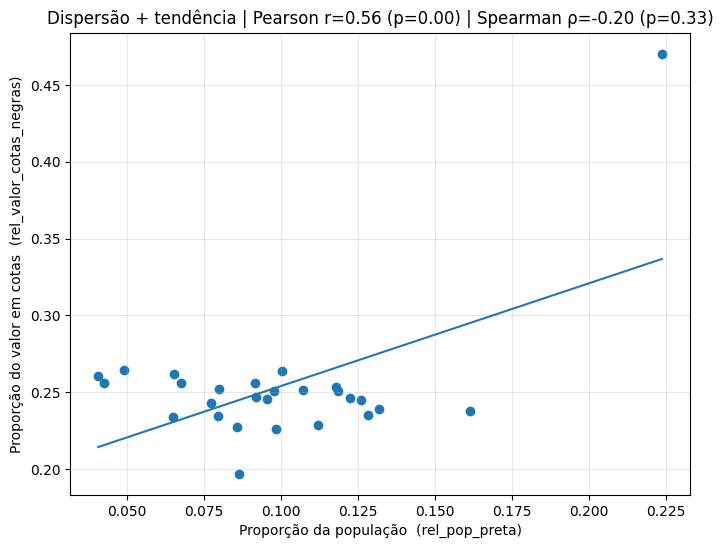

In [25]:
# PESSOAS PRETAS
print(corr(df=df_sniic_censo_estados, col_x='rel_pop_preta', col_y='rel_valor_cotas_negras'))
plot_corr(df=df_sniic_censo_estados, col_x='rel_pop_preta', col_y='rel_valor_cotas_negras')

    n  pearson_r  pearson_p  spearman_r  spearman_p
0  53       0.45       0.00        0.32        0.02


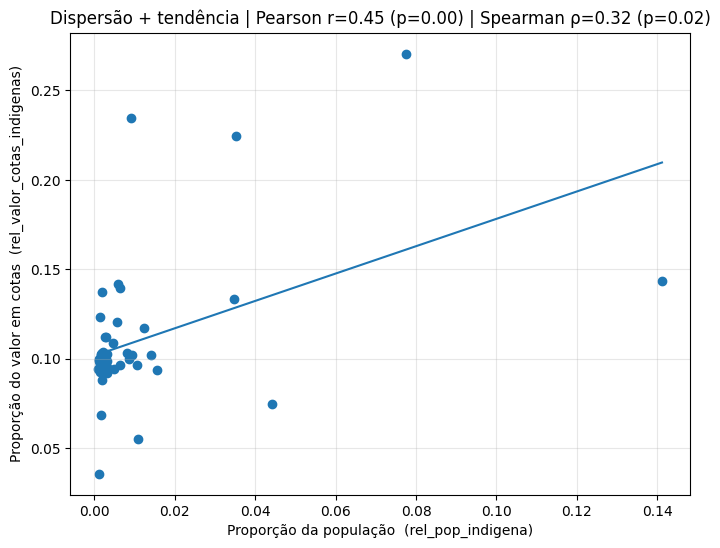

In [29]:
# PESSOAS INDÍGENAS
print(corr(df=df_sniic_censo_geral, col_x='rel_pop_indigena', col_y='rel_valor_cotas_indigenas'))
plot_corr(df=df_sniic_censo_geral, col_x='rel_pop_indigena', col_y='rel_valor_cotas_indigenas')

    n  pearson_r  pearson_p  spearman_r  spearman_p
0  53       0.02       0.88        0.11        0.42


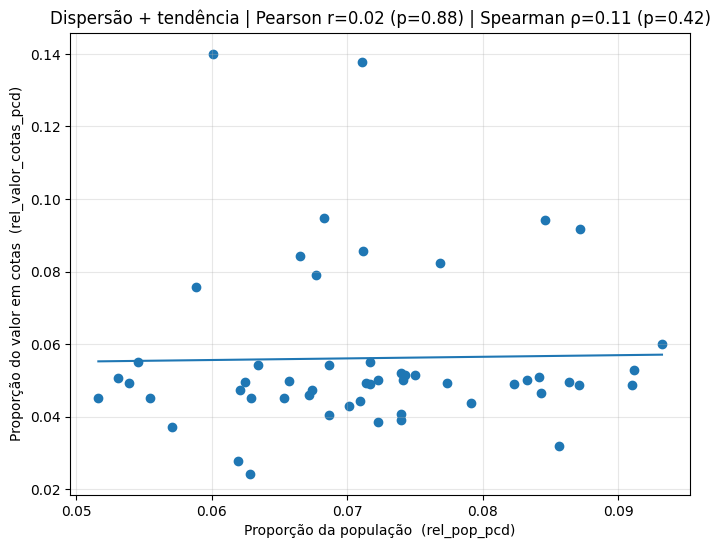

In [31]:
# PCD
print(corr(df=df_sniic_censo_geral, col_x='rel_pop_pcd', col_y='rel_valor_cotas_pcd'))
plot_corr(df=df_sniic_censo_geral, col_x='rel_pop_pcd', col_y='rel_valor_cotas_pcd')

In [26]:
df_sniic_censo_geral.to_excel('base_demografica_05_02_26_14_44.xlsx')